In [ ]:
from utils import * 
import subprocess
import json
import itertools
import requests

%load_ext autoreload 
%autoreload 2

In [ ]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id == 5].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_1.faa')
# subprocess.run('muscle -align ../data/genes/cluster_1.faa -output ../data/genes/cluster_1.afa', shell=True, check=True)
for row in genes_df.itertuples():
    print(f'{row.Index}')

print('\nMinimum cluster_1 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_1 gene length:', genes_df.seq.apply(len).max())

orfm.bz_0.1_175
orfm.bz_1.1_148
orfm.bz_2.1_34
orfm.bz_3.1_50
orfm.bz_4.1_164
orfm.bz_5.1_140
orfm.bz_7.1_180
orfm.bz_8.1_206
orfm.bz_9.1_49
orfm.bz_10.1_18
orfm.bz_11.1_39

Minimum cluster_1 gene length: 138
Maximum cluster_1 gene length: 153


In [ ]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    
for row in genes_df.itertuples():
    print(f'Number TMHs in {row.genome_id} cluster_1 protein:', row.num_tmhs)


Number TMHs in bz_0 cluster_1 protein: 0
Number TMHs in bz_1 cluster_1 protein: 0
Number TMHs in bz_2 cluster_1 protein: 0
Number TMHs in bz_3 cluster_1 protein: 0
Number TMHs in bz_4 cluster_1 protein: 0
Number TMHs in bz_5 cluster_1 protein: 0
Number TMHs in bz_7 cluster_1 protein: 0
Number TMHs in bz_8 cluster_1 protein: 0
Number TMHs in bz_9 cluster_1 protein: 0
Number TMHs in bz_10 cluster_1 protein: 0
Number TMHs in bz_11 cluster_1 protein: 0


In [ ]:
COLABFOLD_DIR = '../data/genes/colabfold'
DSSP_OUTPUT_DIR = '../data/genes/dssp/'
DSSP_INPUT_DIR = '../data/genes/dssp/structures/cluster_5/'

copy_structures(genes_df.index.tolist(), source_dir=COLABFOLD_DIR, output_dir=DSSP_INPUT_DIR)

for path in glob.glob(os.path.join(DSSP_INPUT_DIR, '*')):
    gene_id = get_gene_id(path)
    output_path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
    if not os.path.exists(output_path):
        subprocess.run(f'mkdssp {path} {output_path} --output-format dssp', shell=True, check=True)

def map_dssp_to_msa(msa):
    ids, arr = list(), list()
    for gene_id, map_idxs in msa.get_map_idxs().items():
        path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
        row = np.array(list(str(DSSPFile.from_file(path))) + ['.'])
        arr.append(row[map_idxs])
        ids.append(gene_id)
    return MSA.from_array(arr, ids)

msa = MSA.from_file('../data/genes/cluster_5.afa')
dssp_msa = map_dssp_to_msa(msa)
    

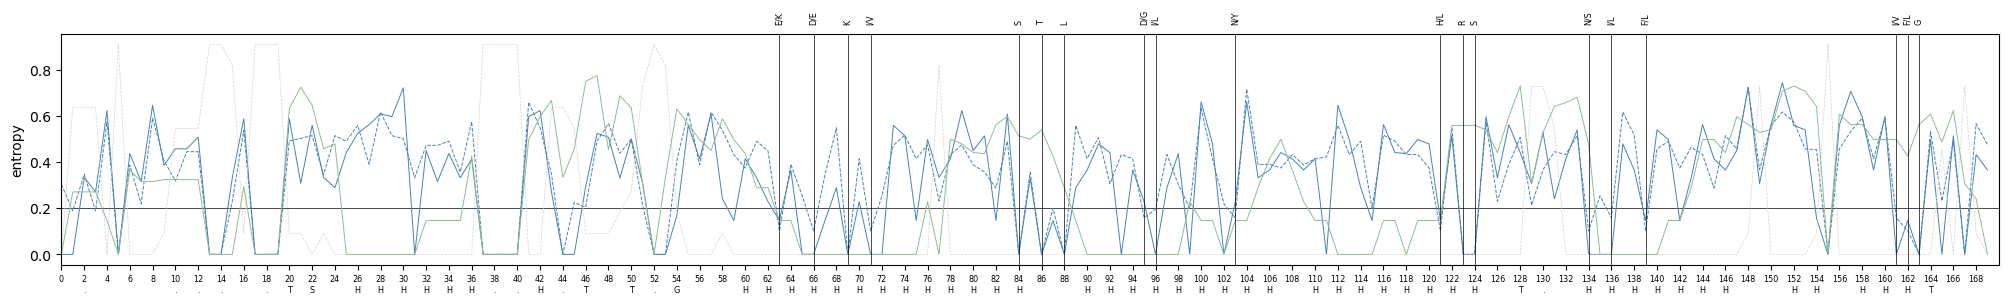

In [ ]:
def get_entropy(msa, alphabet:dict=None, exclude_gaps:bool=False, alphabet_size:int=20):

    alphabet_size = alphabet_size if (alphabet is None) else len(np.unique(list(alphabet.values())))

    entropy = list()
    for col in msa.to_array(alphabet=alphabet).T:
        if (exclude_gaps and (MSA.gap_symbol in col)) or (len(col[col != MSA.gap_symbol]) == 0):
            entropy.append(np.nan)
            continue 
        _, counts = np.unique(col[col != MSA.gap_symbol], return_counts=True)
        frequencies = counts / counts.sum()
        entropy.append(sum(-(frequencies * np.log(frequencies) / np.log(alphabet_size))))
    return np.array(entropy)

fig, ax = plt.subplots(figsize=(25, 3))

MAX_ENTROPY = 0.2

x_min, x_max = 0, 170 

lines = dict()
lines['entropy'] = get_entropy(msa)
lines['entropy (reduced)'] = get_entropy(msa, alphabet=REDUCED_ALPHABET)
lines['gap fraction'] = [(col == MSA.gap_symbol).mean() for col in msa.to_array().T]
lines['entropy (DSSP)'] = get_entropy(dssp_msa, alphabet_size=len(DSSPFile.code_map))

kwargs = dict()
kwargs['entropy'] = {'color':'steelblue', 'lw':0.7, 'ls':'--'}
kwargs['entropy (reduced)'] = {'color':'steelblue', 'lw':0.7, 'ls':'-'}
kwargs['gap fraction'] = {'color':'lightgray', 'lw':0.5, 'ls':'--'}
kwargs['entropy (DSSP)'] = {'color':'darkseagreen', 'lw':0.7, 'ls':'-'}

for label, line in lines.items():
    ax.plot(np.arange(msa.n_cols), line, label=label, **kwargs.get(label))

conserved_idxs = np.where((lines['entropy'] < MAX_ENTROPY) & (~np.isnan(lines['entropy'])))[0] 
conserved_idxs = [idx for idx in conserved_idxs if (MSA.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

for idx, aas in zip(conserved_idxs, conserved_aas):
    if (idx > x_max) or (idx < x_min):
        continue
    ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
    ax.axvline(idx, color='black', lw=0.5)


ax.set_xlim(xmin=x_min, xmax=x_max)
ax.set_ylabel('entropy')
ax.axhline(MAX_ENTROPY, color='black', zorder=-1, lw=0.5)

dssp_consensus = dssp_msa.get_consensus()
x_ticks = np.arange(x_min, x_max, 2)
x_tick_labels = [f'{x}\n{dssp_consensus[x]}' for x in x_ticks]
ax.set_xticks(x_ticks, x_tick_labels, fontsize='xx-small')

plt.show()


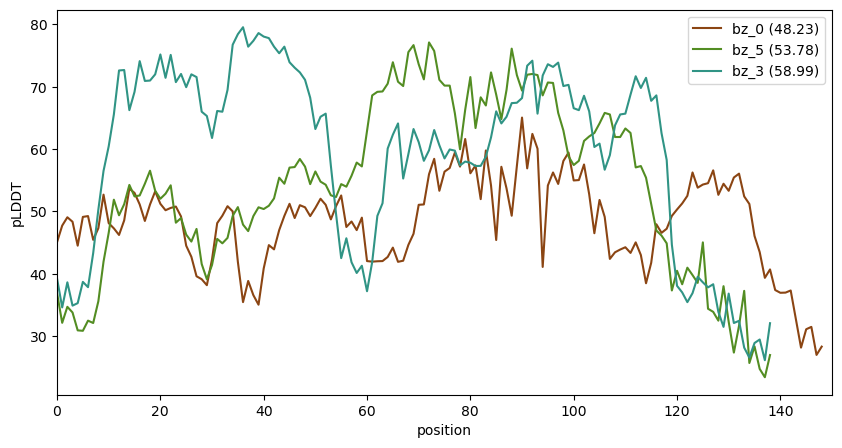

In [ ]:
plddts = load_colabfold_plddts(gene_ids=genes_df.index.values)
mean_plddts = {gene_id:np.mean(plddts_) for gene_id, plddts_ in plddts.items()}


fig, ax = plt.subplots(figsize=(10, 5))

figure_df = pd.DataFrame.from_dict(plddts, orient='index').T
figure_df = figure_df.reset_index(names='position')
figure_df = figure_df.melt(id_vars='position', value_name='pLDDT', var_name='gene_id')
figure_df['genome_id'] = figure_df.gene_id.apply(get_genome_id)
figure_df['label'] = figure_df.gene_id.apply(lambda gene_id : f'{get_genome_id(gene_id)} ({mean_plddts[gene_id]:.2f})')
figure_df = figure_df[figure_df.genome_id.isin(['bz_3', 'bz_5', 'bz_0'])]

cmap = LinearSegmentedColormap.from_list('palette',  ['saddlebrown', 'darkgoldenrod', 'olivedrab', 'forestgreen', 'darkseagreen', 'teal', 'steelblue', 'slateblue'])
palette = {label:cmap(i / figure_df.label.nunique()) for i, label in enumerate(figure_df.label.unique())}

# for gene_id, plddts_ in plddts.items():
#     ax.plot(np.arange(len(plddts_)), plddts_, color=palette[gene_id], label=get_genome_id(gene_id), lw=0.7)
sns.lineplot(figure_df, x='position', y='pLDDT', hue='label', palette=palette)

ax.legend()
ax.set_xlim(xmin=0, xmax=150)
plt.show()

In [ ]:
# None of the InterProScan annotations on these proteins are particularly helpful... 
# The NCBI BLAST hits are also unhelpful. 

# INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
# annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
# annot_df = annot_df[annot_df.gene_id.isin(genes_df.index)].copy()

In [ ]:
FOLDSEEK_FIELDS = ['query', 'target', 'evalue', 'gapopen', 'pident', 'fident', 'nident', 'qstart', 'qend', 'qlen', 'tstart', 'tend', 'tlen', 'alnlen', 'bits', 'cigar', 'qseq', 'tseq', 'qheader', 'theader', 'qaln', 'taln', 'mismatch', 'qcov', 'tcov','taxid', 'taxname', 'taxlineage', 'lddt', 'lddtfull', 'qtmscore', 'ttmscore', 'alntmscore', 'rmsd', 'prob']
FOLDSEEK_TARGET_DATABASE_PATTERN = r'alphafold_swissprot|alphafold_uniprot|pdb|bfvd'
TMHMM_PATH = '../data/genes/tmhmm/cluster_5_targets.txt'

paths = {re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path).group(0):path for path in glob.glob('../data/genes/foldseek/*') if re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path)}
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(target_database=target_database) for target_database, path in paths.items()])
foldseek_search_df = foldseek_search_df[foldseek_search_df['query'].isin(genes_df.index.values)].copy()
foldseek_search_df['num_gaps'] = [max(row.qaln.count('-'), row.taln.count('-')) for row in foldseek_search_df.itertuples()]
foldseek_search_df = foldseek_search_df.drop(columns=['cigar', 'qtmscore', 'ttmscore', 'qheader', 'rmsd', 'fident', 'pident', 'nident', 'taxid'], errors='ignore')

tmhmm_df = pd.read_csv(TMHMM_PATH, sep=r'\s+', comment='#', names=['id', 'version', 'annotation', 'start', 'stop'])
tmhmm_df = tmhmm_df[tmhmm_df.annotation == 'TMhelix'].copy()
foldseek_search_df['target_has_tmh'] = foldseek_search_df.target.isin(tmhmm_df['id'].unique())

print('Number of unique Foldseek hits:', foldseek_search_df.target.nunique())

# FASTAFile.from_df(foldseek_search_df.drop_duplicates('target').set_index('target').rename(columns={'tseq':'seq'})).write('../data/genes/foldseek/cluster_5_targets.faa') # Write targets to a FASTA file for other analysis.

filters = dict()
filters['large_e_value'] = foldseek_search_df.evalue > 0.5
filters['low_tm_score'] = foldseek_search_df.alntmscore < 0.5
filters['eukaryotic'] = foldseek_search_df.taxlineage.str.contains('Eukaryota') | foldseek_search_df.theader.str.contains('human')
filters['low_query_coverage'] = foldseek_search_df.qcov < 0.5
filters['low_target_coverage'] = foldseek_search_df.tcov < 0.5
filters['synthetic'] = foldseek_search_df.theader.str.contains('Computationally designed|synthetic|de novo|De novo')
filters['target_too_long'] = foldseek_search_df.tlen > 300 
filters['fragment'] = foldseek_search_df.theader.str.contains('fragment', case=False)
filters['has_transmembrane_helix'] = foldseek_search_df.target_has_tmh # Seems to be a lot of hits for small membrane proteins that are probably false positives. 
filters['synthetic'] = foldseek_search_df.theader.str.contains('designed|engineered|deep learning', case=False)

# Seems to be several hits with only the AlphaFold accession, though some of these are annotated in the AlphaFold database. 
ALPHAFOLD_ACCESSION_PATTERN = r'[A-Z0-9]+$'
foldseek_search_targets_missing_annotation = foldseek_search_df[foldseek_search_df.theader.str.match(ALPHAFOLD_ACCESSION_PATTERN)].theader.values 
foldseek_search_targets_missing_annotation = np.unique(foldseek_search_targets_missing_annotation)
print('Number of Foldseek hits with only the AlphaFold accession provided:', len(foldseek_search_targets_missing_annotation))

foldseek_search_df = apply_filters(filters, foldseek_search_df).sort_values('bits')
print()

for gene_id, df in foldseek_search_df.groupby('query'):
    num_hits_by_target_database = df.value_counts('target_database')
    num_hits_by_target_database = [f'{target_database} ({n})' for target_database, n in zip(num_hits_by_target_database.index, num_hits_by_target_database.values)]
    num_hits_by_target_database = ' '.join(num_hits_by_target_database)
    print(f'Number of filtered Foldseek hits for {gene_id}:', len(df), f'\t{num_hits_by_target_database}')

print('\nNumber of Foldseek hits after filtering:', len(foldseek_search_df))
print('Number of unique Foldseek hits after filtering:', foldseek_search_df.target.nunique())

Number of unique Foldseek hits: 5419
Number of Foldseek hits with only the AlphaFold accession provided: 1602
apply_filters: 7 entries removed by large_e_value.
apply_filters: 3519 entries removed by low_tm_score.
apply_filters: 1673 entries removed by eukaryotic.
apply_filters: 556 entries removed by low_query_coverage.
apply_filters: 1466 entries removed by low_target_coverage.
apply_filters: 28 entries removed by synthetic.
apply_filters: 1525 entries removed by target_too_long.
apply_filters: 126 entries removed by fragment.
apply_filters: 1746 entries removed by has_transmembrane_helix.

Number of filtered Foldseek hits for orfm.bz_0.1_175: 14 	bfvd (7) pdb (5) alphafold_uniprot (1) alphafold_swissprot (1)
Number of filtered Foldseek hits for orfm.bz_1.1_148: 21 	bfvd (14) alphafold_uniprot (4) pdb (2) alphafold_swissprot (1)
Number of filtered Foldseek hits for orfm.bz_10.1_18: 20 	bfvd (17) alphafold_uniprot (3)
Number of filtered Foldseek hits for orfm.bz_11.1_39: 11 	bfvd (8) 

In [ ]:
ALPHAFOLD_METADATA_PATH = '../data/genes/cluster_5_alphafold_metadata.tsv'

if not os.path.exists(ALPHAFOLD_METADATA_PATH):
    alphafold_metadata_df = list()
    for accession in tqdm(foldseek_search_targets_missing_annotation, desc='Obtaining additional annotation information from AlphaFold.'):
        url = f'https://alphafold.ebi.ac.uk/api/prediction/{accession}'
        result = requests.get(url).text
        if result == 'error':
            continue
        alphafold_metadata_df += json.loads(result)

    alphafold_metadata_df = pd.DataFrame(alphafold_metadata_df).set_index('uniprotAccession')
    alphafold_metadata_df.to_csv(ALPHAFOLD_METADATA_PATH)

else:
    alphafold_metadata_df = pd.read_csv(ALPHAFOLD_METADATA_PATH, index_col=0)

UNCHARACTERIZED_PROTEIN_PATTERN = list()
UNCHARACTERIZED_PROTEIN_PATTERN += ['putative membrane protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['polyprotein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['putative phage protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized phage protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['membrane protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized membrane protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['putative orfan'] 
UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane domain-containing protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['coil containing protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['ankyrin repeat incomplete domain containing protein']

alphafold_metadata_df['uniprotDescription'] = alphafold_metadata_df.uniprotDescription.fillna('Uncharacterized protein')
alphafold_metadata_df['uncharacterized'] = alphafold_metadata_df.uniprotDescription.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)

print('Number of additional retrieved annotations:', (~alphafold_metadata_df.uncharacterized).sum())

annotations = alphafold_metadata_df.set_index('uniprotAccession').uniprotDescription.to_dict()
foldseek_search_df['theader'] = foldseek_search_df.theader.apply(lambda theader : annotations.get(theader, theader))
foldseek_search_df['uncharacterized'] = foldseek_search_df.theader.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)

Number of additional retrieved annotations: 391


In [ ]:
UNCHARACTERIZED_PROTEIN_PATTERN += ['2huj-assembly1_A']
UNCHARACTERIZED_PROTEIN_PATTERN += ['7yh8-assembly2_C']
UNCHARACTERIZED_PROTEIN_PATTERN += ['SaV']
UNCHARACTERIZED_PROTEIN_PATTERN += ['four helix bundle protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['Uncharacterized 15.3 kDa protein']

foldseek_search_categories = dict()
foldseek_search_categories['ZapD'] = foldseek_search_df.theader.str.contains('ZapD') # Stabilizes tubulin formation during cell division. 
foldseek_search_categories['ScdA'] = foldseek_search_df.theader.str.contains('ScdA')
foldseek_search_categories['uncharacterized'] = foldseek_search_df.theader.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)
foldseek_search_categories['cytochrome c subunit 3'] = foldseek_search_df.theader.str.contains('cytochrome c|cytochrome oxidase|heme-copper oxidase', case=False) # This is membrane-associated
foldseek_search_categories['large ribosomal subunit bL17'] = foldseek_search_df.theader.str.contains('bL17')
foldseek_search_categories['rhodopsin'] = foldseek_search_df.theader.str.contains('rhodopsin|rhdopsin', case=False)
foldseek_search_categories['lipoprotein'] = foldseek_search_df.theader.str.contains('lipoprotein', case=False)
foldseek_search_categories['DUF*'] = foldseek_search_df.theader.str.contains('DUF', case=True)
foldseek_search_categories['membrane kinase'] = foldseek_search_df.theader.str.contains('kinase') 
foldseek_search_categories['sugar translocase'] = foldseek_search_df.theader.str.contains('GtrA|sugar translocase') # Small membrane protein involved in cell surface mofification. 
foldseek_search_categories['ATP synthase subunit A'] = foldseek_search_df.theader.str.contains('ATP synthase') # Membrane region. 
foldseek_search_categories['nucleotide pyrophosphate hydrolysis'] = foldseek_search_df.theader.str.contains('pyrophosphatase|MazZ')
foldseek_search_categories['transcriptional regulator'] = foldseek_search_df.theader.str.contains('FasR|transcriptional regulator|repressor protein CI|cro/C1', case=False)
foldseek_search_categories['LEF-11'] = foldseek_search_df.theader.str.contains('Late expression factor') # Possibly really interesting, involved in late stages of viral life cycle.
foldseek_search_categories['ribosomal subunit'] = foldseek_search_df.theader.str.contains('70S|Small ribosomal subunit protein bS6')
foldseek_search_categories['late transcription elongation factor'] = foldseek_search_df.theader.str.contains('OPG087') # Possibly involved in forming transcription machinery late in viral life cycles.
foldseek_search_categories['secreted protein'] = foldseek_search_df.theader.str.contains('secreted', case=False)
foldseek_search_categories['DNA binding'] = foldseek_search_df.theader.str.contains('DNA transfer protein p3|AcrF3|DnaA|DNA-binding|DNA binding|BINDS AND PROTECTS DNA|DPS protein from ferritin superfamily')
foldseek_search_categories['RNA polymerase-associated'] = foldseek_search_df.theader.str.contains('DksA|RNA polymerase specialized sigma subunit|sigma factor') # DksA ontrols transcription by binding to RNA polymerase.
foldseek_search_categories['flagella'] = foldseek_search_df.theader.str.contains('flagellar|chemotaxis', case=False) # Controls transcription by binding to RNA polymerae.
foldseek_search_categories['terminase'] = foldseek_search_df.theader.str.contains('terminase', case=False) # Controls transcription by binding to RNA polymerae.

foldseek_search_df['category'] = np.select(*list(zip(*list(foldseek_search_categories.items())))[::-1], default='none')



In [ ]:
foldseek_search_df.sort_values('evalue')[['theader']].iloc[0].theader
foldseek_search_df[foldseek_search_df.category == 'none'].theader.tolist()
foldseek_search_df[foldseek_search_df.category != 'uncharacterized'].sort_values('alntmscore')[['theader']].theader.tolist()

foldseek_search_df[foldseek_search_df.category == 'DNA binding'][['alntmscore', 'qlen', 'tlen', 'theader']]

,alntmscore,qlen,tlen,theader
96208,0.5182,147,157,6b0d-assembly1_C An E. coli DPS protein from f...
96199,0.5283,147,159,"1dps-assembly1_A THE CRYSTAL STRUCTURE OF DPS,..."
19761,0.5040,150,160,Helix-turn-helix DNA binding protein
92891,0.6601,142,225,DNA transfer protein p32
29149,0.5510,138,109,"Chromosomal replication initiator, DnaA C-term..."
92803,0.5878,142,183,Dps DNA-binding ferritin-like protein (Oxidati...
101693,0.5271,139,135,5gnf-assembly1_B Crystal structure of anti-CRI...
92784,0.6398,142,215,Ribbon-helix-helix DNA binding domain protein


In [ ]:
genes_df.iloc[0].seq

'MSKEKESLENETGFSEKQTAFITNLFTGKGGIFDRPQGQGGDATNDLKELEAIKLILSMIGNKEFIKSATNLPEGELDDINDAEMINSYADCPELDEYIKNRLELSRSRIQPNGQYNNLLRLLTDISGKTGMQFSNMGEYNKILGKMGR'

In [ ]:
seq = 'GAGAGAGAGTACACTTCCACCACTCAGACACTCTATAAATTCCCATCTGAAGTAAAT'
# print(seq.replace('T', 'U'))
print(seq)
print(reverse_complement(seq))

GAGAGAGAGTACACTTCCACCACTCAGACACTCTATAAATTCCCATCTGAAGTAAAT
ATTTACTTCAGATGGGAATTTATAGAGTGTCTGAGTGGTGGAAGTGTACTCTCTCTC
